In [ ]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"

columns = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
    "class"
]

df = pd.read_csv(url, names=columns)
df.head()

In [3]:
import piplite
await piplite.install(['seaborn', 'pandas', 'matplotlib'])

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
columns = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
    "class"
]
df = pd.read_csv("iris.csv",names=columns)

In [5]:
print("--- Feature Information ---")
print(df.info())
print("\nFeature Types:")
print(df.dtypes)

--- Feature Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   class         150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 5.3+ KB
None

Feature Types:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
class            object
dtype: object


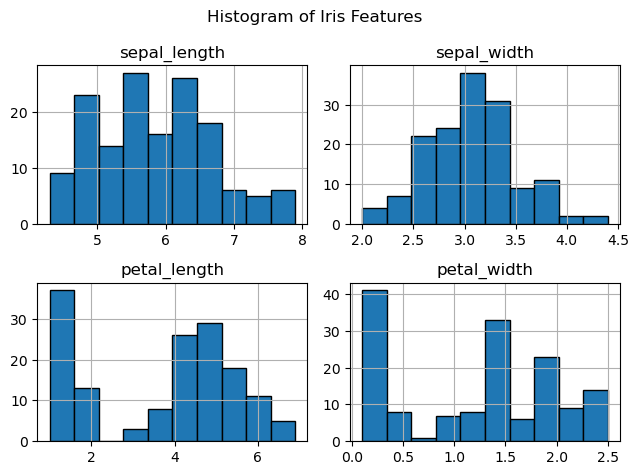

In [6]:
# Requirement 2: Histograms for each feature
# We use a subplot layout for better visualization
#df.hist(figsize=(10, 8), bins=15, edgecolor='black')
df.hist(edgecolor='black')
plt.suptitle("Histogram of Iris Features")
plt.tight_layout()

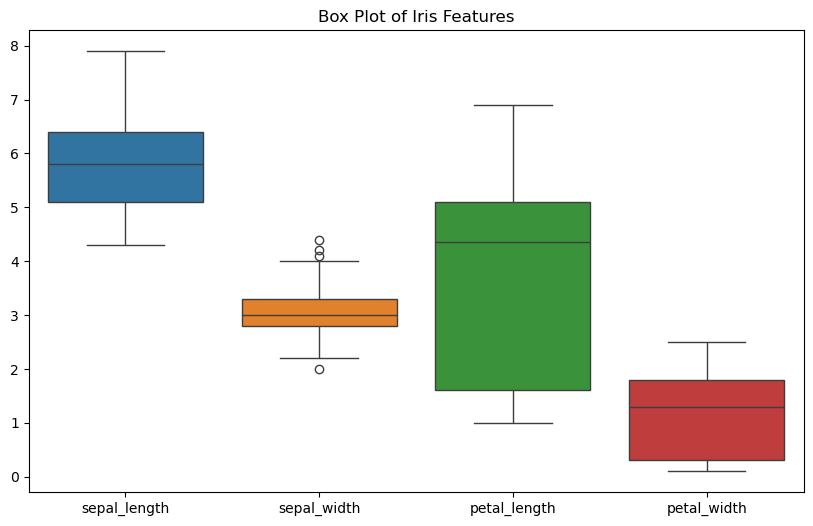

In [19]:
# Requirement 3: Box plots for each feature
plt.figure(figsize=(10, 6))
sns.boxplot(data=df)
plt.title("Box Plot of Iris Features")
plt.show()

Text(0.5, 1.0, 'Sepal Width by Species (Check for Outliers)')

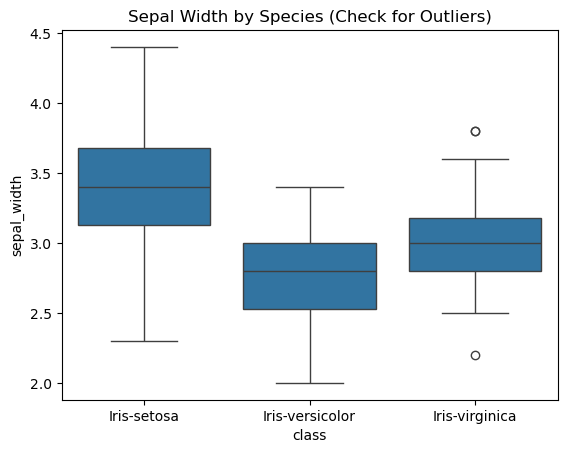

In [35]:
# Requirement 4: Compare distributions by Species (to identify patterns/outliers)

sns.boxplot(x='class', y='sepal_width', data=df)
plt.title("Sepal Width by Species (Check for Outliers)")



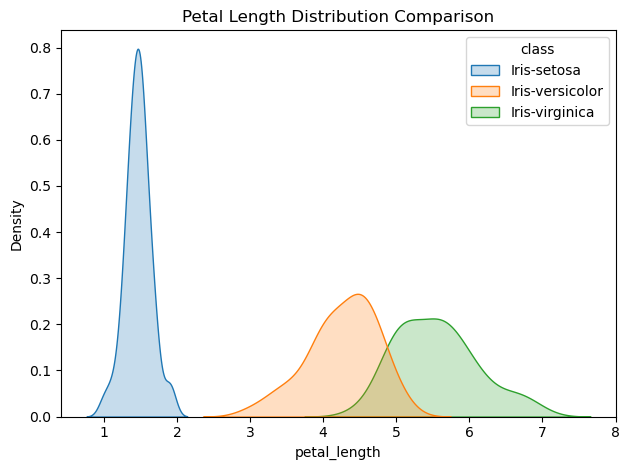

In [36]:
sns.kdeplot(data=df, x='petal_length', hue='class', fill=True)
plt.title("Petal Length Distribution Comparison")

plt.tight_layout()
plt.show()

In [38]:
# Ultra-simplified Outlier Check
for col in ["sepal_length", "sepal_width", "petal_length", "petal_width"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} outliers")

sepal_length: 0 outliers
sepal_width: 4 outliers
petal_length: 0 outliers
petal_width: 0 outliers


In [40]:
for column in df.drop(columns=["class"]).columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    print(f"\nFeature: {column}")
    print(f"Lower Bound: {lower_bound:.2f}")
    print(f"Upper Bound: {upper_bound:.2f}")
    print(f"Number of Outliers: {len(outliers)}")



Feature: sepal_length
Lower Bound: 3.15
Upper Bound: 8.35
Number of Outliers: 0

Feature: sepal_width
Lower Bound: 2.05
Upper Bound: 4.05
Number of Outliers: 4

Feature: petal_length
Lower Bound: -3.65
Upper Bound: 10.35
Number of Outliers: 0

Feature: petal_width
Lower Bound: -1.95
Upper Bound: 4.05
Number of Outliers: 0
